# 03A — PPO + MaskablePPO + MinigridCNN (egocentric image obs)

Direct port of legacy [`train_ppo_mask_imgobs.py`](../../corner-maze-rl-legacy/experiments/train_ppo_mask_imgobs.py) into the new repo. SB3 `MaskablePPO` with the standard `CnnPolicy` trunk, `MinigridFeaturesExtractor` as the features extractor, env wrapped with `ImgObsWrapper` then `ActionMasker(mask_fn)`. One run = one (seed × session sequence) pass through `train.runner.run_session_sequence`. Acquisition is capped at `TOTAL_SESSIONS` rat-protocol sessions (criterion-stop fires when the env declares acquisition); if criterion doesn't fire, probes are skipped and the run is marked KILL_HARD_CAP. Optional `KILL_FLAT` early-kill catches dead acquisitions before the cap.

Configuration matches the legacy script (`N_STEPS=256, BATCH_SIZE=64, N_EPOCHS=4, LEARNING_RATE=1e-4, TOTAL_TIMESTEPS=5e5, FEATURES_DIM=128, GAMMA=0.999, GAE_LAMBDA=0.95, ENT_COEF=0.05, VF_COEF=0.5, CLIP_RANGE=0.2`). All constants are exposed at the top — same pattern as the legacy `.py` scripts so a student can read this notebook side-by-side with the legacy file.

Per-seed artifacts under `runs/{RUN_NAME}_{timestamp}/seed_{N}/`:
- `run_config.json` — seed + git_sha + hparams + `environment` (python/torch/CUDA/MPS + full `pip freeze`)
- `curves.parquet` — one row per `(session_type, phase)`: `phase ∈ {acquisition, probe_frozen, probe_updating}`, with `score` (headline: peak episode for acquisition/probe_updating, frozen-eval mean for probe_frozen), tag-aware breakdown (`<tag>_mean`, `<tag>_possible_mean`), `n_episodes`, `wall_clock_seconds`, plus frozen-eval fields (`score_frozen_mean/std/min/max`, `n_eval_episodes`)
- `eval_summary.parquet` — one row per frozen-eval episode of each probe (`score`, `n_steps`, `total_reward`, `ss_<tag>` fields)
- `trial_metrics.parquet` — one row per trial across all sessions/episodes: `tag`, `score`, `start_arm/cue/goal`, `policy_mode`
- `action_stats.parquet` — one row per episode: action distribution (`action_{0..4}_count` / `_freq`)
- `episode_data.parquet` — full per-step trajectory rows from env (nested cols JSON-encoded)
- `killed_at.json` — only if a kill fired; `reason` ∈ {`hit_session_cap`, `flat_learning`, `did_not_acquire`}
- `model_post_acquisition.zip`, `model_post_probes.zip`, **`model_best.zip`** (best-score checkpoint)
- `sb3_logs/progress.csv` + `sb3_logs/events.out.tfevents.*` — SB3 logger: entropy, KL, value loss, explained variance, clip fraction, policy-gradient loss, lr, fps, plus `maze/flat_slope` / `maze/flat_recent_mean` when KILL_FLAT diagnostics are active

Per-run aggregates at the run-name root:
- `aggregate.parquet` — rat-comparable metrics with IQM + 95% bootstrap CI: `acquired_fraction`, `n_sessions_to_acquire`, `score_peak_acquisition`, `probe_rate_<label>` per probe
- `performance_profile.parquet` — CDF of per-(run × probe) frozen-eval rates at each τ ([agarwal-2021] §4.3)

## 1. Configuration

In [12]:
from __future__ import annotations

from datetime import datetime, timezone
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from minigrid.wrappers import ImgObsWrapper
from sb3_contrib.common.wrappers import ActionMasker
from sb3_contrib.ppo_mask import MaskablePPO
from stable_baselines3.common.callbacks import CallbackList
from stable_baselines3.common.logger import configure as sb3_logger_configure

from corner_maze_rl.data.session_types import assert_subject_group_match
from corner_maze_rl.encoders.visual import MinigridFeaturesExtractor
from corner_maze_rl.env.corner_maze_env import CornerMazeEnv
from corner_maze_rl.env.wrappers import mask_fn
from corner_maze_rl.train.runner import run_session_sequence
from corner_maze_rl.train.sb3_callbacks import (
    ActionStatsCallback,
    BestModelCallback,
    CriterionStopCallback,
    FlatLearningKillCallback,
    MaxAcquisitionEpisodesCallback,
    TrainingProgressCallback,
)

# ── Experiment ────────────────────────────────────────────────
RUN_NAME           = 'ppo-imgobs-pi+vc'
EXPERIMENT_NOTES   = 'Baseline PPO session with egocentric view from minigrid env'

# ── Subject / group / session sequence ────────────────────────
TRAINING_GROUP     = 'pi'                   # 'pi' | 'pi_vc' | 'vc' | 'pi_vc_f1'
SUBJECT            = None                   # or 'CM023' (PI) for provenance; None skips validation
# ── Configuration ──────────────────────────────
# Valid session_type values:
#   'exposure', 'exposure_b',
#   'PI+VC f2 single trial', 'PI+VC f2 acquisition', 'PI+VC f2 novel route',
#   'PI+VC f2 no cue', 'PI+VC f2 rotate', 'PI+VC f2 reversal',
#   'PI+VC f1 acquisition', 'PI+VC f1 novel route', 'PI+VC f1 no cue',
#   'PI+VC f1 rotate', 'PI+VC f1 reversal',
#   'PI acquisition', 'PI novel route no cue', 'PI novel route cue',
#   'PI reversal no cue', 'PI reversal cue',
#   'VC acquisition', 'VC novel route fixed', 'VC novel route rotate',
#   'VC reversal fixed', 'VC reversal rotate'
SESSION_TYPES      = [
    'PI+VC f2 acquisition',
    'PI+VC f2 novel route',
    'PI+VC f2 no cue',
    'PI+VC f2 rotate',
    'PI+VC f2 reversal',
]
ORIENTATION        = 'N/NE'
GOAL_LOCATION      = 'NE'

# ── Run sweep ─────────────────────────────────────────────────
# One run = one independent (seed × full session sequence) pass. Seeds
# are simply 0..N_RUNS-1; per-run dirs are seed_0/, seed_1/, ...
N_RUNS             = 5                  # smoke=2, iteration=10, headline=30

# ── Env step duration (from legacy yoked-data analysis) ───────
# Median rat step time ≈ 260ms; pause duration ≈ 500ms. PAUSE (action 4)
# is masked off here via mask_fn so pauses don't apply, but noted for the
# record. Analysis done extensively in the legacy repo — not re-derived.
STEP_SECONDS       = 0.260

# ── Per-session-type episode caps ─────────────────────────────
# One PPO episode = one rat behavioral session. Acquisition is a fixed
# 48-min session; probes run for 180s × n_trials. Trial counts per
# session_type (from rat behavior):
#   acquisition          = 48 min fixed       →  2880s
#   novel route          = 40 trials × 180s   →  7200s
#   reversal             = 80 trials × 180s   → 14400s
#   rotate (PI+VC)       = 16 trials × 180s   →  2880s
#   no cue / dark probe  = 32 trials × 180s   →  5760s
def steps_for(session_type: str) -> int:
    s = session_type.lower()
    if   'acquisition' in s: seconds = 48 * 60
    elif 'novel route' in s: seconds = 180 * 40
    elif 'reversal'    in s: seconds = 180 * 80
    elif 'rotate'      in s: seconds = 180 * 16
    elif 'no cue'      in s: seconds = 180 * 32   # PI+VC dark probe
    else:
        raise ValueError(f'no STEPS rule for session_type={session_type!r}')
    return int(seconds / STEP_SECONDS)

STEPS_BY_SESSION_TYPE = {st: steps_for(st) for st in SESSION_TYPES}

# ── Acquisition session cap (rat-protocol convention) ─────────
# Rats are given up to TOTAL_SESSIONS acquisition sessions to reach
# criterion; runs that don't acquire by then are dropped. The agent
# follows the same rule via MaxAcquisitionEpisodesCallback. Applies to
# acquisition phases only — probes run unaffected. If a run hits this
# cap without `training_criterion_met` firing, the runner emits
# killed_at.json with decision=KILL_HARD_CAP and skips remaining probes.
TOTAL_SESSIONS     = 50

# ── Flat-learning kill (intra-acquisition) ────────────────────
# Optional early-kill for acquisition runs that are clearly not learning.
# Per-episode score slope < 0.05 trials/session AND mean < 4 perfect
# trials over the trailing 10-episode window → stop early. Off by
# default for rat-faithful runs. KILL_FLAT_WARMUP is the minimum number
# of acquisition episodes before the kill can fire — rats wouldn't get
# more than ~25 sessions of dead behavior, but the model deserves a
# longer warm-up since it starts from zero knowledge of the task.
KILL_FLAT          = True
KILL_FLAT_WARMUP   = 21

# ── Training budget (multi-episode) ───────────────────────────
# Cumulative env-step cap for model.learn() during each acquisition
# session_type. NOT the per-episode cap (that's steps_for()). Required
# by SB3; with TOTAL_SESSIONS in place this is a fallback that almost
# never fires (TOTAL_SESSIONS hits first at 80 × ~11_077 ≈ 886k steps,
# unless episodes finish early under criterion progress).
#   smoke=2e4, iteration=2e5, headline=5e5
TOTAL_TIMESTEPS    = int(5e5)

# ── Probe frozen-eval ─────────────────────────────────────────
# Number of frozen evaluation episodes per probe session_type. Runner
# loops `frozen_fn` this many times with fresh envs and writes one
# row per eval to `eval_summary.parquet`. With FROZEN_DETERMINISTIC=False
# below, each eval samples the stochastic policy — N>1 gives a CI on
# probe generalization rather than a single noisy datapoint.
EVAL_EPISODES_PER_PROBE = 1

# —— Model Config ——————————————————————————————————————————————
ALGORITHM ='maskablePPO'
POLICY = 'cnn_policy'
FEATURE_EXTRACTOR = 'MinigridFeaturesExtractor'

# ── MaskablePPO hyperparameters (legacy parity) ───────────────
N_STEPS            = 256
BATCH_SIZE         = 64
N_EPOCHS           = 4
LEARNING_RATE      = 1e-4
GAMMA              = 0.999
GAE_LAMBDA         = 0.95
ENT_COEF           = 0.05
VF_COEF            = 0.5
CLIP_RANGE         = 0.2
MAX_GRAD_NORM      = 0.5
FEATURES_DIM       = 128

# ── Misc ──────────────────────────────────────────────────────
FROZEN_DETERMINISTIC = False
FORCE_CPU            = False

# ── Device detection ──────────────────────────────────────────
if FORCE_CPU:
    DEVICE = 'cpu'
elif torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
print(f'device={DEVICE}')

REPO_ROOT = Path('..').resolve()
RUNS_ROOT = REPO_ROOT / 'runs'
RUNS_ROOT.mkdir(parents=True, exist_ok=True)
print(f'repo_root={REPO_ROOT}')
print(f'steps_per_session_type={STEPS_BY_SESSION_TYPE}')

device=mps
repo_root=/Users/ryangrgurich/Code/python-dev/corner-maze-rl
steps_per_session_type={'PI+VC f2 acquisition': 11076, 'PI+VC f2 novel route': 27692, 'PI+VC f2 no cue': 22153, 'PI+VC f2 rotate': 11076, 'PI+VC f2 reversal': 55384}


## 2. Subject ↔ group validation

If `SUBJECT` is set, look up its training group in `subjects.parquet` and assert the pair matches. With `SUBJECT=None` this is skipped — free runs don't need a rat, just a paradigm sequence.

In [13]:
if SUBJECT is not None:
    subjects_path = REPO_ROOT / 'data' / 'yoked' / 'dataset' / 'subjects.parquet'
    subjects = pd.read_parquet(subjects_path)
    row = subjects[subjects['subject_name'] == SUBJECT]
    if row.empty:
        raise ValueError(f'SUBJECT={SUBJECT!r} not found in {subjects_path}')
    subject_group_label = row.iloc[0].get('training_group') or row.iloc[0].get('group')
    GROUP_ALIASES = {'pi_vc': 'PI+VC', 'pi': 'PI', 'vc': 'VC', 'pi_vc_f1': 'PI+VC_f1'}
    assert_subject_group_match(
        training_group=GROUP_ALIASES[TRAINING_GROUP],
        subject_training_group=subject_group_label,
    )
    print(f'subject={SUBJECT}  group={subject_group_label}  → matches TRAINING_GROUP={TRAINING_GROUP}')
else:
    print(f'subject=None (validation skipped) → TRAINING_GROUP={TRAINING_GROUP} drives env paradigms')

print('session sequence:')
for st in SESSION_TYPES:
    kind = 'acquisition' if 'acquisition' in st.lower() else 'probe'
    print(f'  - {kind:11s} {st}')

subject=None (validation skipped) → TRAINING_GROUP=pi drives env paradigms
session sequence:
  - acquisition PI+VC f2 acquisition
  - probe       PI+VC f2 novel route
  - probe       PI+VC f2 no cue
  - probe       PI+VC f2 rotate
  - probe       PI+VC f2 reversal


## 3. Env / model / training plumbing

Definitions kept inline (per the legacy-script style) so all the `MaskablePPO(...)` knobs — including `policy_kwargs={'features_extractor_class': MinigridFeaturesExtractor, ...}` — are visible right where you'd edit them. The runner ([src/corner_maze_rl/train/runner.py](../src/corner_maze_rl/train/runner.py)) calls these as `train_fn(env_wrapped)` / `frozen_fn(env_wrapped)` / `save_fn(path)` per session.

Model state survives across sessions inside the per-seed loop: the first call to `train_fn` constructs the `MaskablePPO`, subsequent calls reuse it via `model.set_env(env_wrapped)` so the policy carries over from acquisition into probes.

In [14]:
# Per-seed state. Bound by reset_seed_state() at the top of each seed loop.
# Holds the model (carried across all train_fn calls in one seed), the
# seed itself, the per-seed output dir (needed by callbacks for paths),
# and an ActionStatsCallback instance shared across all train_fn calls
# so action-distribution stats accumulate across acquisition + probe phases.
_state = {'model': None, 'seed': None, 'seed_dir': None, 'action_cb': None}

POLICY_KWARGS = dict(
    features_extractor_class=MinigridFeaturesExtractor,
    features_extractor_kwargs=dict(features_dim=FEATURES_DIM),
)

def make_env(session_type: str):
    env_raw = CornerMazeEnv(
        render_mode='rgb_array',
        max_steps=steps_for(session_type),
        agent_cue_goal_orientation=ORIENTATION,
        start_goal_location=GOAL_LOCATION,
        session_type=session_type,
        obs_mode='view',
    )
    env_wrapped = ImgObsWrapper(env_raw)
    env_wrapped = ActionMasker(env_wrapped, mask_fn)
    return env_wrapped, env_raw

def train_fn(env_wrapped):
    # Detect acquisition vs probe from the underlying env so the
    # TOTAL_SESSIONS cap and FlatLearningKill are enforced only on
    # acquisition phases (probes stay unaffected).
    raw = env_wrapped.unwrapped
    is_acq = 'acquisition' in (getattr(raw, 'session_type', '') or '').lower()

    callback_list = [
        TrainingProgressCallback(),
        CriterionStopCallback(),
        BestModelCallback(save_path=str(_state['seed_dir'] / 'model_best')),
        _state['action_cb'],
    ]
    if is_acq:
        callback_list.append(MaxAcquisitionEpisodesCallback(max_episodes=TOTAL_SESSIONS))
        callback_list.append(FlatLearningKillCallback(
            warmup=KILL_FLAT_WARMUP,
            enabled=KILL_FLAT,
        ))
    callbacks = CallbackList(callback_list)

    if _state['model'] is None:
        _state['model'] = MaskablePPO(
            'CnnPolicy',
            env_wrapped,
            n_steps=N_STEPS,
            batch_size=BATCH_SIZE,
            n_epochs=N_EPOCHS,
            gamma=GAMMA,
            gae_lambda=GAE_LAMBDA,
            learning_rate=LEARNING_RATE,
            ent_coef=ENT_COEF,
            vf_coef=VF_COEF,
            clip_range=CLIP_RANGE,
            max_grad_norm=MAX_GRAD_NORM,
            policy_kwargs=POLICY_KWARGS,
            device=DEVICE,
            verbose=0,
            seed=_state['seed'],
        )
        # Persist SB3 logger to seed_dir/sb3_logs/ so train/entropy_loss,
        # train/approx_kl, train/value_loss, train/explained_variance,
        # train/clip_fraction, train/policy_gradient_loss, time/fps and
        # the rollout/maze/* records all hit progress.csv + TensorBoard.
        sb3_log_dir = _state['seed_dir'] / 'sb3_logs'
        sb3_log_dir.mkdir(parents=True, exist_ok=True)
        _state['model'].set_logger(
            sb3_logger_configure(str(sb3_log_dir), ['stdout', 'csv', 'tensorboard'])
        )
    else:
        _state['model'].set_env(env_wrapped)
    _state['model'].learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=callbacks,
        reset_num_timesteps=False,
    )

def frozen_fn(env_wrapped):
    obs, _ = env_wrapped.reset()
    done = False
    while not done:
        action_masks = np.array(mask_fn(env_wrapped))
        action, _ = _state['model'].predict(
            obs, deterministic=FROZEN_DETERMINISTIC, action_masks=action_masks,
        )
        obs, _, terminated, truncated, _ = env_wrapped.step(action)
        done = bool(terminated or truncated)

def save_fn(path: str):
    _state['model'].save(f'{path}.zip')

def reset_seed_state(seed: int, seed_dir: Path):
    """Reset per-seed state. Call once at the top of each seed iteration."""
    _state['model']     = None
    _state['seed']      = seed
    _state['seed_dir']  = Path(seed_dir)
    _state['action_cb'] = ActionStatsCallback(n_actions=5)

print('env/model/train hooks defined')

env/model/train hooks defined


## 4. Per-seed run loop

In [ ]:
timestamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S')
RUN_ROOT  = RUNS_ROOT / f'{RUN_NAME}_{timestamp}'
RUN_ROOT.mkdir(parents=True, exist_ok=False)
print(f'run_root={RUN_ROOT}')

HPARAMS = dict(
    n_steps=N_STEPS, batch_size=BATCH_SIZE,
    step_seconds=STEP_SECONDS,
    steps_per_session_type=STEPS_BY_SESSION_TYPE,
    total_sessions=TOTAL_SESSIONS,
    kill_flat=KILL_FLAT,
    kill_flat_warmup=KILL_FLAT_WARMUP,
    total_timesteps=TOTAL_TIMESTEPS,
    eval_episodes_per_probe=EVAL_EPISODES_PER_PROBE,
    features_dim=FEATURES_DIM,
    n_epochs=N_EPOCHS, gamma=GAMMA, gae_lambda=GAE_LAMBDA,
    learning_rate=LEARNING_RATE, ent_coef=ENT_COEF, vf_coef=VF_COEF,
    clip_range=CLIP_RANGE, max_grad_norm=MAX_GRAD_NORM,
)

seed_results = []
for seed in range(N_RUNS):
    print(f'\n=== seed {seed} ===')
    seed_dir = RUN_ROOT / f'seed_{seed}'
    seed_dir.mkdir(parents=True, exist_ok=False)
    reset_seed_state(seed, seed_dir)

    result = run_session_sequence(
        session_types=SESSION_TYPES,
        make_env=make_env,
        train_fn=train_fn,
        frozen_fn=frozen_fn,
        save_fn=save_fn,
        save_data_path=str(seed_dir / 'episode_data.parquet'),
        model_save_dir=str(seed_dir),
        seed=seed,
        run_dir=str(seed_dir),
        eval_episodes_per_probe=EVAL_EPISODES_PER_PROBE,
        run_config_extra={
            'run_name':             RUN_NAME,
            'experiment_notes':     EXPERIMENT_NOTES,
            'algorithm':            ALGORITHM,
            'policy':               POLICY,
            'features_extractor':   FEATURE_EXTRACTOR,
            'subject':              SUBJECT,
            'training_group':       TRAINING_GROUP,
            'orientation':          ORIENTATION,
            'goal_location':        GOAL_LOCATION,
            'session_types':        SESSION_TYPES,
            'hparams':              HPARAMS,
            'device':               DEVICE,
            'frozen_deterministic': FROZEN_DETERMINISTIC,
        },
    )
    # Dump action-distribution stats accumulated across all train_fn calls.
    _state['action_cb'].to_parquet(seed_dir / 'action_stats.parquet')

    print(f'  decision={result.decision.value}  n_sessions={result.n_sessions_run}  scores={result.scores}')
    seed_results.append({'seed': seed, 'scores': result.scores, 'decision': result.decision.value})

print(f'\ndone: {len(seed_results)} runs → {RUN_ROOT}')

run_root=/Users/ryangrgurich/Code/python-dev/corner-maze-rl/runs/ppo-imgobs-pi+vc_20260521T022251

=== seed 0 ===
Logging to /Users/ryangrgurich/Code/python-dev/corner-maze-rl/runs/ppo-imgobs-pi+vc_20260521T022251/seed_0/sb3_logs
-----------------------------
| maze/               |     |
|    best_at_timestep | 0   |
|    best_score       | -1  |
|    episode          | 0   |
|    episode_cap_hit  | 0   |
|    n_episodes       | 0   |
|    reward           | 0   |
|    score            | 0   |
|    trials           | 0   |
| time/               |     |
|    fps              | 123 |
|    iterations       | 1   |
|    time_elapsed     | 2   |
|    total_timesteps  | 256 |
-----------------------------
-------------------------------------------
| maze/                   |               |
|    best_at_timestep     | 0             |
|    best_score           | -1            |
|    episode              | 0             |
|    episode_cap_hit      | 0             |
|    n_episodes           

## 5. Cross-run aggregation — rat-comparable metrics

Loads per-run data once (used by §6 viz too) and emits two artifacts at the run root:

- **`aggregate.parquet`** — one row per metric, schema `{metric, scope, value, ci_low, ci_high, n}`. Metrics under rat-protocol training:
  - `acquired_fraction` (scope=all_runs) — fraction of runs that reached criterion within `TOTAL_SESSIONS`. No CI; it's a count.
  - `n_sessions_to_acquire` (scope=acquired_only) — IQM + 95% bootstrap CI over the runs that acquired. The headline learning-speed metric.
  - `score_peak_acquisition` (scope=all_runs) — IQM of best single-episode perfect-trial count during acquisition. Sanity check that the policy ever reached high performance even if it didn't sustain it to criterion.
  - `probe_rate_<label>` (scope=acquired_only) — IQM + CI per probe label (Novel Route / Dark / Rotate / Reversal) using the `PROBE_SCORING` dict.

- **`performance_profile.parquet`** — CDF of "fraction of (run × probe) pairs scoring ≥ τ" across τ ∈ [0, 1] ([agarwal-2021] §4.3). Computed over frozen-eval probe rates only — the rat-comparable generalization measure.

Mean-over-last-K windowing was dropped because it collapses to ~criterion threshold for criterion-stopped runs. See runner.py docstring for the full rationale.

In [5]:
def _iqm(x: np.ndarray) -> float:
    if x.size == 0:
        return float('nan')
    q1, q3 = np.percentile(x, [25, 75])
    middle = x[(x >= q1) & (x <= q3)]
    return float(middle.mean()) if middle.size else float(x.mean())

def _bootstrap_iqm_ci(x: np.ndarray, n_boot: int = 500, alpha: float = 0.05, rng=None):
    if x.size == 0:
        return float('nan'), float('nan')
    rng = rng or np.random.default_rng(0)
    boots = np.array([_iqm(rng.choice(x, size=x.size, replace=True)) for _ in range(n_boot)])
    return float(np.percentile(boots, 100 * alpha / 2)), float(np.percentile(boots, 100 * (1 - alpha / 2)))


# ── Probe scoring config (rat-comparable) ─────────────────────
# Maps env session_type → (label, tag filter, possible-per-session).
# Denominator = possible_per_session × n_eval_episodes_actually_ran.
# tag=None means "count all trials" (Dark, Rotate); tag='novel' or
# 'reversal' means only that trial-type's correct count is the numerator.
PROBE_SCORING = {
    'PI novel route no cue':  {'label': 'Novel Route', 'tag': 'novel',    'possible': 16},
    'PI reversal no cue':     {'label': 'Reversal',    'tag': 'reversal', 'possible': 64},
    'PI novel route cue':     {'label': 'Novel Route', 'tag': 'novel',    'possible': 16},
    'PI reversal cue':        {'label': 'Reversal',    'tag': 'reversal', 'possible': 64},
    'PI+VC f2 novel route':   {'label': 'Novel Route', 'tag': 'novel',    'possible': 16},
    'PI+VC f2 no cue':        {'label': 'Dark',        'tag': None,       'possible': 32},
    'PI+VC f2 rotate':        {'label': 'Rotate',      'tag': None,       'possible': 16},
    'PI+VC f2 reversal':      {'label': 'Reversal',    'tag': 'reversal', 'possible': 64},
    'PI+VC f1 novel route':   {'label': 'Novel Route', 'tag': 'novel',    'possible': 16},
    'PI+VC f1 no cue':        {'label': 'Dark',        'tag': None,       'possible': 32},
    'PI+VC f1 rotate':        {'label': 'Rotate',      'tag': None,       'possible': 16},
    'PI+VC f1 reversal':      {'label': 'Reversal',    'tag': 'reversal', 'possible': 64},
    'VC novel route fixed':   {'label': 'Novel Route', 'tag': 'novel',    'possible': 16},
    'VC novel route rotate':  {'label': 'Novel Route', 'tag': 'novel',    'possible': 16},
    'VC reversal fixed':      {'label': 'Reversal',    'tag': 'reversal', 'possible': 64},
    'VC reversal rotate':     {'label': 'Reversal',    'tag': 'reversal', 'possible': 64},
}

# ── Load per-run acquisition + probe data ─────────────────────
# Used by both the §5 aggregation here and §6 viz below.
# A run is "acquired" iff no killed_at.json exists (criterion fired).
acq_records   = []
probe_records = []
for sd in sorted(RUN_ROOT.glob('seed_*')):
    seed = int(sd.name.removeprefix('seed_'))
    ed_path = sd / 'episode_data.parquet'
    tm_path = sd / 'trial_metrics.parquet'
    if not ed_path.exists():
        continue

    ed = pd.read_parquet(ed_path)
    acq = ed[(ed['session_type'].str.contains('acquisition', case=False, na=False)) &
             (ed['policy_mode'] == 'updating')]
    n_sessions = int(len(acq))
    n_steps    = int(acq['total_steps'].sum()) if 'total_steps' in acq.columns and n_sessions else 0

    # Best single-episode perfect_trial_count during acquisition.
    score_peak = 0
    for _, row in acq.iterrows():
        ts = row.get('trial_scores')
        if isinstance(ts, str):
            ts = json.loads(ts)
        score_peak = max(score_peak, int(sum(1 for s in (ts or []) if s)))

    killed_path = sd / 'killed_at.json'
    if killed_path.exists():
        with open(killed_path) as f:
            killed = json.load(f)
        criterion_met = False
        kill_reason   = killed.get('reason', 'did_not_acquire')
    else:
        criterion_met = True
        kill_reason   = None

    acq_records.append({
        'seed': seed,
        'n_sessions':    n_sessions,
        'n_steps':       n_steps,
        'score_peak':    score_peak,
        'criterion_met': criterion_met,
        'kill_reason':   kill_reason,
    })

    if not tm_path.exists():
        continue
    trials = pd.read_parquet(tm_path)
    frozen = trials[trials['policy_mode'] == 'frozen']
    for st in frozen['session_type'].dropna().unique():
        if st not in PROBE_SCORING:
            continue
        cfg = PROBE_SCORING[st]
        sub_all   = frozen[frozen['session_type'] == st]
        sub_relev = sub_all if cfg['tag'] is None else sub_all[sub_all['tag'] == cfg['tag']]
        n_eval_episodes  = int(sub_all['episode'].nunique())
        n_possible_total = int(cfg['possible'] * n_eval_episodes)
        n_correct        = int((sub_relev['score'] == 1).sum())
        rate = n_correct / n_possible_total if n_possible_total > 0 else float('nan')
        probe_records.append({
            'seed': seed, 'session_type': st, 'label': cfg['label'],
            'n_correct': n_correct, 'n_possible': n_possible_total,
            'n_eval_episodes': n_eval_episodes, 'rate': rate,
        })

acq_df   = pd.DataFrame(acq_records).sort_values('seed').reset_index(drop=True)
probe_df = pd.DataFrame(probe_records)

# ── Cross-run aggregate metrics (rat-comparable) ──────────────
agg_rows = []
if not acq_df.empty:
    n_runs       = len(acq_df)
    acquired     = acq_df['criterion_met'].to_numpy(dtype=bool)
    n_acq        = int(acquired.sum())

    # acquired_fraction — simple proportion, no CI
    agg_rows.append({
        'metric': 'acquired_fraction', 'scope': 'all_runs',
        'value':  n_acq / n_runs if n_runs else float('nan'),
        'ci_low': float('nan'), 'ci_high': float('nan'), 'n': n_runs,
    })

    # n_sessions_to_acquire — over acquired runs only
    sessions = acq_df.loc[acquired, 'n_sessions'].to_numpy(dtype=float)
    if sessions.size:
        ci_lo, ci_hi = _bootstrap_iqm_ci(sessions, rng=np.random.default_rng(0))
        agg_rows.append({
            'metric': 'n_sessions_to_acquire', 'scope': 'acquired_only',
            'value':  _iqm(sessions), 'ci_low': ci_lo, 'ci_high': ci_hi,
            'n':      int(sessions.size),
        })

    # score_peak_acquisition — over all runs (acquired or not)
    peaks = acq_df['score_peak'].to_numpy(dtype=float)
    if peaks.size:
        ci_lo, ci_hi = _bootstrap_iqm_ci(peaks, rng=np.random.default_rng(1))
        agg_rows.append({
            'metric': 'score_peak_acquisition', 'scope': 'all_runs',
            'value':  _iqm(peaks), 'ci_low': ci_lo, 'ci_high': ci_hi,
            'n':      int(peaks.size),
        })

# probe_rate_<label> — over acquired runs (only acquired runs ran probes)
if not probe_df.empty:
    for i, lab in enumerate(sorted(probe_df['label'].dropna().unique())):
        rates = probe_df.loc[probe_df['label'] == lab, 'rate'].dropna().to_numpy(dtype=float)
        if rates.size:
            ci_lo, ci_hi = _bootstrap_iqm_ci(rates, rng=np.random.default_rng(100 + i))
            metric_name = f"probe_rate_{lab.lower().replace(' ', '_')}"
            agg_rows.append({
                'metric': metric_name, 'scope': 'acquired_only',
                'value':  _iqm(rates), 'ci_low': ci_lo, 'ci_high': ci_hi,
                'n':      int(rates.size),
            })

aggregate = pd.DataFrame(agg_rows)
aggregate.to_parquet(RUN_ROOT / 'aggregate.parquet')

# ── Performance profile (agarwal-2021 §4.3): CDF over probe rates ─
if probe_df.empty:
    profile = pd.DataFrame(columns=['tau', 'fraction_at_least'])
else:
    tau_grid = np.linspace(0.0, 1.0, 100)
    rates    = probe_df['rate'].dropna().to_numpy(dtype=float)
    profile  = pd.DataFrame({
        'tau':               tau_grid,
        'fraction_at_least': [float((rates >= t).mean()) for t in tau_grid],
    })
profile.to_parquet(RUN_ROOT / 'performance_profile.parquet')

print(f'n_runs={len(acq_df)}, acquired={int(acq_df["criterion_met"].sum()) if not acq_df.empty else 0}')
print(f'aggregate rows: {len(aggregate)}, performance_profile points: {len(profile)}')
aggregate

n_runs=5, acquired=0
aggregate rows: 2, performance_profile points: 0


,metric,scope,value,ci_low,ci_high,n
0,acquired_fraction,all_runs,0.0,NaN,NaN,5
1,score_peak_acquisition,all_runs,5.0,2.75,18.75,5


## 6. Visualization — rat vs. agent comparison

Three panels overlaying the current training group's rats (from `data/rat_benchmarks/per_subject.parquet`) against this run's agent seeds. `TRAINING_GROUP` (cell 1) determines which rat cohort is loaded:

1. **Sessions to acquisition** — two violins side-by-side (rats vs. agents). Agent points colored blue if criterion fired, grey/red-edged if censored at the `TOTAL_SESSIONS` cap. Horizontal red dashed line marks the protocol cap.
2. **Steps to acquisition** — same structure; y is total env-steps across acquisition. Rat steps come from yoked-dataset `n_actions` (real-pretrial), agent steps from `acq_df['n_steps']` — apples-to-apples.
3. **Probe performance** — bar plot with two bars per probe label (rats, agents) + individual data scatter overlaid. Only probes that apply to this group per protocol are shown (PI and VC have no Dark/Rotate bars; PI+VC variants have all four).

All three panels use the same color scheme: rats = purple, agents = blue.

loaded 12 rats in group 'PI' from per_subject.parquet


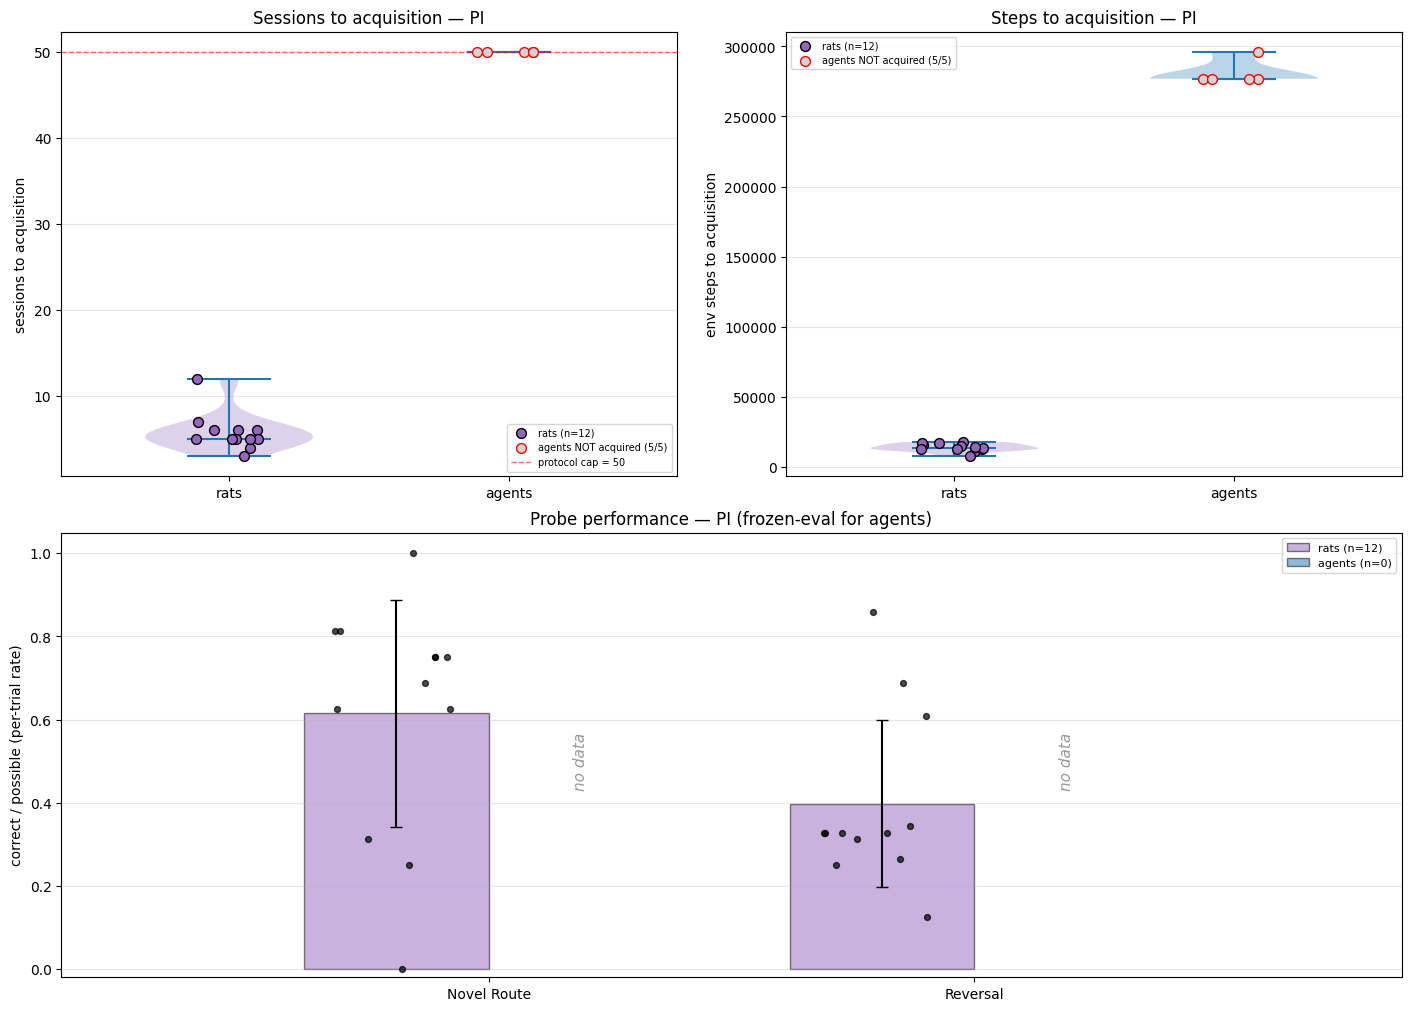


--- rats (PI, n=12) summary ---
       n_sessions_to_acquire  n_steps_to_acquire  rate_novel_route  rate_dark  rate_rotate  rate_reversal
count               12.00000           12.000000         12.000000        0.0          0.0      12.000000
mean                 5.75000        13822.833333          0.614583        NaN          NaN       0.397135
std                  2.22077         2908.866659          0.284337        NaN          NaN       0.209997
min                  3.00000         7559.000000          0.000000        NaN          NaN       0.125000
25%                  5.00000        12402.750000          0.546875        NaN          NaN       0.300781
50%                  5.00000        13439.000000          0.718750        NaN          NaN       0.328125
75%                  6.00000        15980.750000          0.765625        NaN          NaN       0.410156
max                 12.00000        17782.000000          1.000000        NaN          NaN       0.859375

--- agents (

In [11]:
# ── Load rat benchmarks for the current TRAINING_GROUP ───────
# Maps notebook's TRAINING_GROUP token → rat-benchmark training_group label.
RAT_GROUP_ALIASES = {'pi': 'PI', 'pi_vc': 'PI+VC', 'vc': 'VC', 'pi_vc_f1': 'PI+VC_f1'}
rat_group = RAT_GROUP_ALIASES.get(TRAINING_GROUP)

rat_path = REPO_ROOT / 'data' / 'rat_benchmarks' / 'per_subject.parquet'
if rat_path.exists() and rat_group:
    rats_all = pd.read_parquet(rat_path)
    rats_group = rats_all[rats_all['training_group'] == rat_group].copy()
    print(f'loaded {len(rats_group)} rats in group {rat_group!r} from {rat_path.name}')
else:
    rats_group = pd.DataFrame()
    if not rat_path.exists():
        print(f'WARNING: no rat benchmarks at {rat_path} (run scripts/extract_rat_benchmarks.py)')
    elif not rat_group:
        print(f'WARNING: TRAINING_GROUP={TRAINING_GROUP!r} not mapped to a rat group')

# Censor agent sessions-to-acquisition at TOTAL_SESSIONS for the violin
# (non-acquired runs are shown AT the cap, scatter-colored grey/red).
if not acq_df.empty:
    acq_df['n_sessions_censored'] = np.where(
        acq_df['criterion_met'],
        acq_df['n_sessions'],
        TOTAL_SESSIONS,
    )

n_acquired     = int(acq_df['criterion_met'].sum())     if not acq_df.empty else 0
n_not_acquired = int((~acq_df['criterion_met']).sum())  if not acq_df.empty else 0

# ── Colors ────────────────────────────────────────────────────
RAT_COLOR        = 'tab:purple'
AGENT_COLOR      = 'tab:blue'
AGENT_FAIL_COLOR = 'lightgray'

# ── 2-row layout ──────────────────────────────────────────────
# Row 1: acquisition (2 cols — sessions, steps)
# Row 2: probe performance (full width, spans both columns)
fig = plt.figure(figsize=(14, 10), constrained_layout=True)
gs  = fig.add_gridspec(2, 2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])


def _two_group_violin(ax, rat_values, agent_values, agent_criterion_met,
                      ylabel, title, hline=None, hline_label=None):
    """Two side-by-side violins (rats vs. agents) with scatter overlay."""
    rat_arr   = np.asarray(rat_values, dtype=float)
    agent_arr = np.asarray(agent_values, dtype=float)
    met_mask  = np.asarray(agent_criterion_met, dtype=bool)

    # Build violins for whichever groups have data.
    data_lists, positions, colors = [], [], []
    if rat_arr.size:
        data_lists.append(rat_arr);   positions.append(0); colors.append(RAT_COLOR)
    if agent_arr.size:
        data_lists.append(agent_arr); positions.append(1); colors.append(AGENT_COLOR)

    if data_lists:
        parts = ax.violinplot(data_lists, positions=positions, widths=0.6,
                              showmedians=True, showextrema=True)
        for body, color in zip(parts['bodies'], colors):
            body.set_facecolor(color); body.set_alpha(0.3)
    else:
        ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title); return

    rng = np.random.default_rng(0)
    # Rat scatter
    if rat_arr.size:
        jitter = rng.uniform(-0.12, 0.12, rat_arr.size)
        ax.scatter(np.full(rat_arr.size, 0.0) + jitter, rat_arr,
                   color=RAT_COLOR, edgecolor='black', s=50, zorder=3,
                   label=f'rats (n={rat_arr.size})')
    # Agent scatter — split by criterion_met
    if agent_arr.size:
        jitter_a = rng.uniform(-0.12, 0.12, agent_arr.size)
        if met_mask.any():
            ax.scatter(np.full(int(met_mask.sum()), 1.0) + jitter_a[met_mask],
                       agent_arr[met_mask],
                       color=AGENT_COLOR, edgecolor='black', s=50, zorder=3,
                       label=f'agents acquired ({int(met_mask.sum())}/{agent_arr.size})')
        if (~met_mask).any():
            ax.scatter(np.full(int((~met_mask).sum()), 1.0) + jitter_a[~met_mask],
                       agent_arr[~met_mask],
                       color=AGENT_FAIL_COLOR, edgecolor='red', s=50, zorder=3,
                       label=f'agents NOT acquired ({int((~met_mask).sum())}/{agent_arr.size})')

    if hline is not None:
        ax.axhline(hline, color='red', linestyle='--', linewidth=1, alpha=0.6,
                   label=hline_label or f'cap = {hline}')

    ax.set_xticks([0, 1]); ax.set_xticklabels(['rats', 'agents'])
    ax.set_xlim(-0.6, 1.6)
    ax.set_ylabel(ylabel); ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=7, loc='best')


# Row 1 — acquisition violins
_two_group_violin(
    ax1,
    rat_values=rats_group['n_sessions_to_acquire'].dropna().to_numpy() if not rats_group.empty else np.array([]),
    agent_values=acq_df['n_sessions_censored'].to_numpy()              if not acq_df.empty    else np.array([]),
    agent_criterion_met=acq_df['criterion_met'].to_numpy()             if not acq_df.empty    else np.array([]),
    ylabel='sessions to acquisition',
    title=f'Sessions to acquisition — {rat_group or TRAINING_GROUP}',
    hline=TOTAL_SESSIONS, hline_label=f'protocol cap = {TOTAL_SESSIONS}',
)
_two_group_violin(
    ax2,
    rat_values=rats_group['n_steps_to_acquire'].dropna().to_numpy() if not rats_group.empty else np.array([]),
    agent_values=acq_df['n_steps'].to_numpy()                       if not acq_df.empty    else np.array([]),
    agent_criterion_met=acq_df['criterion_met'].to_numpy()          if not acq_df.empty    else np.array([]),
    ylabel='env steps to acquisition',
    title=f'Steps to acquisition — {rat_group or TRAINING_GROUP}',
)

# Row 2 — probe performance, two bars per probe (rats vs agents)
RAT_RATE_COLS = {
    'Novel Route': 'rate_novel_route',
    'Dark':        'rate_dark',
    'Rotate':      'rate_rotate',
    'Reversal':    'rate_reversal',
}

# Probes to show = union of (rats with non-NaN rate) ∪ (agents with probe data),
# kept in canonical order.
labels_in_protocol = set()
if not rats_group.empty:
    for lab, col in RAT_RATE_COLS.items():
        if col in rats_group.columns and rats_group[col].notna().any():
            labels_in_protocol.add(lab)
if not probe_df.empty:
    labels_in_protocol.update(set(probe_df['label'].dropna().unique()) & set(RAT_RATE_COLS))
labels_in_protocol = [lab for lab in RAT_RATE_COLS if lab in labels_in_protocol]

if not labels_in_protocol:
    ax3.text(0.5, 0.5, 'no probe data', ha='center', va='center', transform=ax3.transAxes)
    ax3.set_title(f'Probe performance — {rat_group or TRAINING_GROUP}')
else:
    bar_width = 0.38
    x_pos = np.arange(len(labels_in_protocol))
    rat_means,   rat_stds,   rat_pts   = [], [], []
    agent_means, agent_stds, agent_pts = [], [], []
    for lab in labels_in_protocol:
        # Rats
        col = RAT_RATE_COLS[lab]
        r = (rats_group[col].dropna().to_numpy()
             if (not rats_group.empty and col in rats_group.columns) else np.array([]))
        rat_means.append(float(r.mean())      if r.size else float('nan'))
        rat_stds.append(float(r.std(ddof=0))  if r.size else float('nan'))
        rat_pts.append(r)
        # Agents
        a = (probe_df.loc[probe_df['label'] == lab, 'rate'].dropna().to_numpy()
             if not probe_df.empty else np.array([]))
        agent_means.append(float(a.mean())      if a.size else float('nan'))
        agent_stds.append(float(a.std(ddof=0))  if a.size else float('nan'))
        agent_pts.append(a)

    # Bars (NaN means the bar simply isn't drawn for that group;
    # we add a 'no data' text annotation below for any missing group.)
    ax3.bar(x_pos - bar_width/2, rat_means, bar_width, yerr=rat_stds,
            color=RAT_COLOR, alpha=0.5, edgecolor='black', capsize=4,
            label=f'rats (n={len(rats_group)})')
    ax3.bar(x_pos + bar_width/2, agent_means, bar_width, yerr=agent_stds,
            color=AGENT_COLOR, alpha=0.5, edgecolor='black', capsize=4,
            label=f'agents (n={int(probe_df["seed"].nunique()) if not probe_df.empty else 0})')

    # Per-data scatter + vertical 'no data' placeholder where a group is missing.
    rng = np.random.default_rng(0)
    for i, (r, a) in enumerate(zip(rat_pts, agent_pts)):
        if r.size:
            j = rng.uniform(-bar_width/3, bar_width/3, r.size)
            ax3.scatter(np.full(r.size, i - bar_width/2) + j, r,
                        color='black', s=18, zorder=3, alpha=0.7)
        else:
            ax3.text(i - bar_width/2, 0.5, 'no data',
                     rotation=90, ha='center', va='center',
                     fontsize=11, color='gray', alpha=0.8, fontstyle='italic')
        if a.size:
            j = rng.uniform(-bar_width/3, bar_width/3, a.size)
            ax3.scatter(np.full(a.size, i + bar_width/2) + j, a,
                        color='black', s=18, zorder=3, alpha=0.7)
        else:
            ax3.text(i + bar_width/2, 0.5, 'no data',
                     rotation=90, ha='center', va='center',
                     fontsize=11, color='gray', alpha=0.8, fontstyle='italic')

    ax3.set_xticks(x_pos); ax3.set_xticklabels(labels_in_protocol)
    # Pad x-axis so rotated 'no data' text at the rightmost bar has space.
    ax3.set_xlim(-0.5 - bar_width, len(labels_in_protocol) - 0.5 + bar_width)
    ax3.set_ylabel('correct / possible (per-trial rate)')
    ax3.set_ylim(-0.02, 1.05)
    ax3.set_title(f'Probe performance — {rat_group or TRAINING_GROUP} (frozen-eval for agents)')
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.legend(fontsize=8, loc='best')

plt.show()

# ── Print summary tables ──────────────────────────────────────
if not rats_group.empty:
    print(f'\n--- rats ({rat_group}, n={len(rats_group)}) summary ---')
    cols_to_show = ['n_sessions_to_acquire', 'n_steps_to_acquire'] + list(RAT_RATE_COLS.values())
    cols_to_show = [c for c in cols_to_show if c in rats_group.columns]
    print(rats_group[cols_to_show].describe().to_string())

print(f'\n--- agents (n_runs={N_RUNS}, acquired={n_acquired}/{N_RUNS}) ---')
print('acq_df:')
print(acq_df.to_string(index=False))
print('\nprobe_df:')
print(probe_df.to_string(index=False) if not probe_df.empty else '  (empty)')

## 6b. SB3 training diagnostics

Loads each seed's `sb3_logs/progress.csv` (entropy, KL, value loss, explained variance, clip fraction, policy-gradient loss) and plots cross-seed training curves vs `time/total_timesteps`. Watch for: entropy collapsing toward zero (policy degenerate), KL spiking past `target_kl`, explained variance pinned near 0 (value fn not learning).

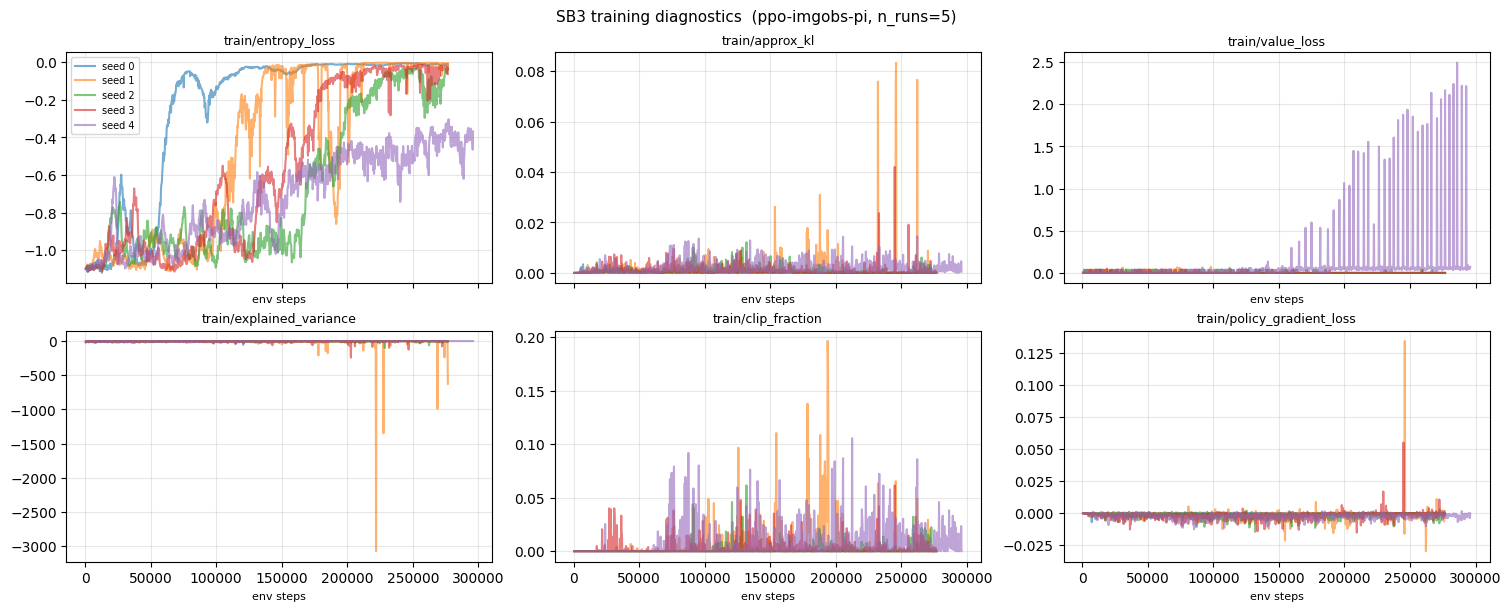

plotted 6 metrics from 5 run(s)


In [10]:
prog_paths = sorted(RUN_ROOT.glob('seed_*/sb3_logs/progress.csv'))
if not prog_paths:
    print(f'no SB3 progress.csv files found under {RUN_ROOT}')
else:
    progress_frames = []
    for pp in prog_paths:
        df = pd.read_csv(pp)
        df['seed'] = int(pp.parents[1].name.removeprefix('seed_'))
        progress_frames.append(df)
    progress_df = pd.concat(progress_frames, ignore_index=True)

    diag_cols = [
        'train/entropy_loss',
        'train/approx_kl',
        'train/value_loss',
        'train/explained_variance',
        'train/clip_fraction',
        'train/policy_gradient_loss',
    ]
    diag_cols = [c for c in diag_cols if c in progress_df.columns]
    x_col = 'time/total_timesteps' if 'time/total_timesteps' in progress_df.columns else None

    n = len(diag_cols)
    ncols = 3
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3*nrows),
                             constrained_layout=True, sharex=True)
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, diag_cols):
        for seed, sub in progress_df.groupby('seed'):
            sub = sub.dropna(subset=[col])
            x = sub[x_col] if x_col else np.arange(len(sub))
            ax.plot(x, sub[col], alpha=0.6, label=f'seed {seed}')
        ax.set_title(col, fontsize=9)
        ax.grid(True, alpha=0.3)
        if x_col:
            ax.set_xlabel('env steps', fontsize=8)
    for ax in axes[n:]:
        ax.axis('off')
    if N_RUNS <= 8 and axes.size > 0:
        axes[0].legend(fontsize=7, loc='best')
    fig.suptitle(f'SB3 training diagnostics  ({RUN_NAME}, n_runs={N_RUNS})', fontsize=11)
    plt.show()
    print(f'plotted {len(diag_cols)} metrics from {len(prog_paths)} run(s)')

## 6c. Tag-aware trial-type breakdown

For probes the env tags every trial as `trained / probe_trained / novel / reversal` (see `CornerMazeEnv._compute_session_scores`). The cell below loads `trial_metrics.parquet` from every seed and shows success rate per (session_type × tag × policy_mode), so you can see whether the policy is generalizing to novel trials specifically vs just memorizing trained ones. For headline runs this is the table that distinguishes "agent solves the task" from "agent solves the *trained subset* of the task."

         session_type           tag policy_mode  success_rate  n_trials  n_seeds
       PI acquisition       trained    updating      0.467283      4111        5
PI novel route no cue         novel      frozen      0.000000        26        5
PI novel route no cue probe_trained      frozen      0.545455        11        5
PI novel route no cue       trained      frozen      0.485149       101        5
PI novel route no cue         novel    updating      0.062500        16        5
PI novel route no cue probe_trained    updating      0.750000         8        5
PI novel route no cue       trained    updating      0.409091        22        5
   PI reversal no cue      reversal      frozen      0.521875       320        5
   PI reversal no cue       trained      frozen      0.421569       102        5
   PI reversal no cue      reversal    updating      0.468750        64        5
   PI reversal no cue       trained    updating      0.400000        20        5


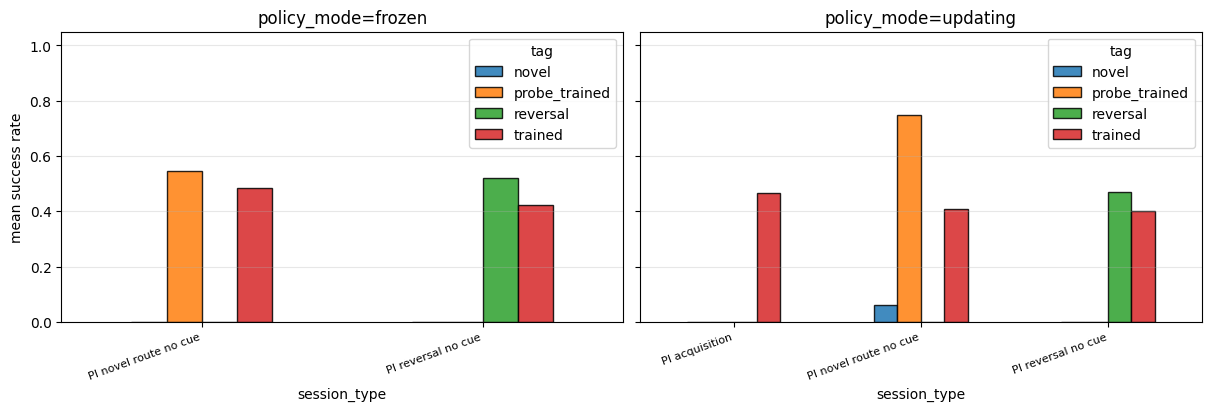

In [9]:
trial_frames = []
for sd in sorted(RUN_ROOT.glob('seed_*')):
    tp = sd / 'trial_metrics.parquet'
    if not tp.exists():
        continue
    df = pd.read_parquet(tp)
    df['seed'] = int(sd.name.removeprefix('seed_'))
    trial_frames.append(df)

if not trial_frames:
    print(f'no trial_metrics.parquet under {RUN_ROOT}')
    trials_df = pd.DataFrame()
else:
    trials_df = pd.concat(trial_frames, ignore_index=True)
    breakdown = (
        trials_df
            .groupby(['session_type', 'tag', 'policy_mode'], dropna=False)
            .agg(success_rate=('score', 'mean'),
                 n_trials=('score', 'count'),
                 n_seeds=('seed', 'nunique'))
            .reset_index()
            .sort_values(['session_type', 'policy_mode', 'tag'])
            .reset_index(drop=True)
    )
    print(breakdown.to_string(index=False))

    # Bar chart: success_rate per (session_type, tag), faceted by policy_mode
    if not breakdown.empty:
        modes = sorted(breakdown['policy_mode'].dropna().unique())
        fig, axes = plt.subplots(1, max(1, len(modes)), figsize=(6*max(1, len(modes)), 4),
                                 constrained_layout=True, sharey=True)
        axes = np.atleast_1d(axes)
        for ax, mode in zip(axes, modes):
            sub = breakdown[breakdown['policy_mode'] == mode]
            pivot = sub.pivot_table(index='session_type', columns='tag',
                                    values='success_rate', aggfunc='mean')
            pivot.plot(kind='bar', ax=ax, edgecolor='black', alpha=0.85)
            ax.set_title(f'policy_mode={mode}'); ax.set_ylabel('mean success rate')
            ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.3, axis='y')
            ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8)
        plt.show()

## 7. Recipes

| Mode      | `N_RUNS`  | `TOTAL_TIMESTEPS` | Expected duration         | Why                                                                                                                                                                |
|-----------|-----------|-------------------|---------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| smoke     | 2         | `int(2e4)`        | a few minutes on GPU      | Confirms env+wrappers+MaskablePPO+CnnPolicy wiring. Not a learning signal — TOTAL_TIMESTEPS is 25× shorter than headline.                                          |
| iteration | 10        | `int(2e5)`        | ~10–30 min per session    | Enough runs and budget to see the learning curve start to bend during dev cycles.                                                                                  |
| headline  | 30        | `int(5e5)`        | many hours on GPU         | Legacy `train_ppo_mask_imgobs.py` defaults. [agarwal-2021] N ≥ 30 for headline IQM. Per-session timestep budget matches a session of rat experience.               |

Switch by editing §1: `N_RUNS` and `TOTAL_TIMESTEPS`. Seeds are simply `0..N_RUNS-1`. Output is fully reproducible from `run_config.json` (seed + git SHA) — re-running with the same `N_RUNS` on a clean working tree reproduces the run.

**Sibling notebooks** (planned):
- `03B_ppo_mlp_embedding.ipynb` — `MaskablePPO` + `MlpPolicy` on the env's 60-D embedding observation. Port of legacy `train_ppo_mask_embedding.py`.
- `03C_ppo_stereo_cnn.ipynb` — `MaskablePPO` with pretrained dual-stream stereo CNN features extractor. Port of legacy `train_ppo_mask_stereo.py`. Requires copying the pretrained TorchScript checkpoint into `data/encoders/`.

**Future SB3 algos.** To try RecurrentPPO or another SB3 algorithm in this notebook's shape, swap `MaskablePPO` for the new class and adjust `policy_kwargs` — the env wrappers, runner, callbacks, and aggregation cells stay identical.